# Getting data into the right format

In order to use `SegTraQ`, you first need to get your data into a `SpatialData` object. While `spatialdata_io` has a lot of readers for different technologies, the constantly evolving landscape of segmentation methods makes it difficult to provide up-to-date, generalizable readers. To facilitate the process of getting your data into the correct format, we provide examples for some segmentation methods.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

## Xenium

For Xenium data, we can make use of the functions from `spatialdata_io`. 

In [3]:
import pandas as pd

test = pd.read_parquet("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium/transcripts.parquet")

In [5]:
transcripts_df = test

In [6]:
fn = transcripts_df["feature_name"]

# Decode bytes to str if needed
if fn.dtype == object and fn.map(type).eq(bytes).any():
    transcripts_df["feature_name"] = fn.map(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)


In [7]:
transcripts_df

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv
0,281474976710656,565,0,SEC11C,4.395842,328.666473,12.019493,18.662479
1,281474976710657,540,0,NegControlCodeword_0502,5.074415,236.964844,7.608510,18.634956
2,281474976710658,562,0,SEC11C,4.702023,322.797150,12.289083,18.662479
3,281474976710659,271,0,DAPK3,4.906601,581.428650,11.222615,20.821745
4,281474976710660,291,0,TCIM,5.660699,720.851746,9.265523,18.017488
...,...,...,...,...,...,...,...,...
42638078,281805689407068,-1,0,HOXD8,5218.000488,5295.519531,30.560934,20.061079
42638079,281805689407071,135717,1,LUM,5218.804688,4792.928223,38.440426,21.389278
42638080,281805689407078,-1,0,LUM,5217.404785,5425.386230,30.519602,21.960102
42638081,281805689407083,-1,0,NARS,5220.155273,4839.704102,32.180698,25.970398


In [3]:
test.uns.pop("log1p", None)
test.write_h5ad("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/BC_scRNAseq_Janesick.h5ad")

In [14]:
import tifffile

img = tifffile.imread("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/outs/morphology_mip.ome.tif")

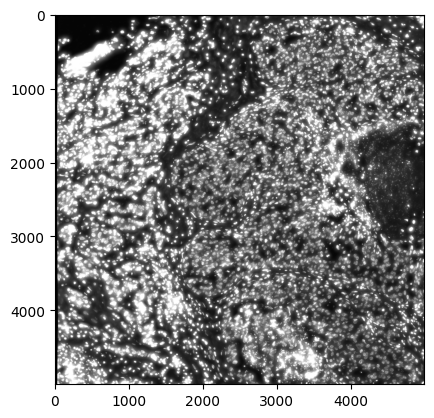

In [15]:
import matplotlib.pyplot as plt

plt.imshow(img[0:5000, 0:5000], cmap='gray', vmin=0, vmax=1000)
plt.show()

In [4]:
import spatialdata_io  # noqa
import segtraq

sdata = spatialdata_io.xenium("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium",
                              cells_as_circles=False,
                              cells_labels=False,
                              nucleus_labels=False,
                              morphology_mip=False)
sdata

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 6444, 8854), (1, 3222, 4427), (1, 1611, 2213)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (167780, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (167780, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


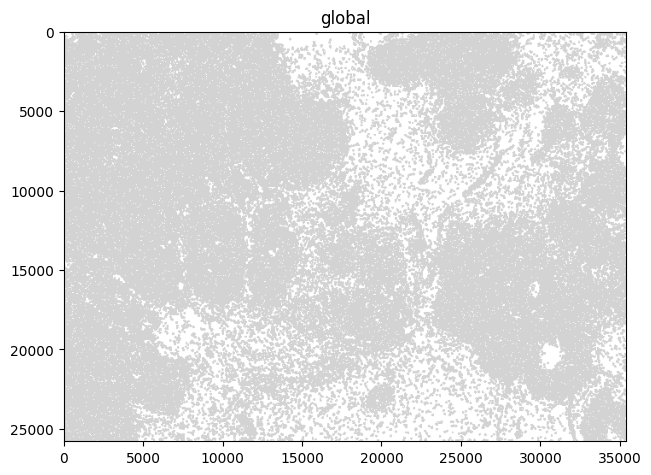

In [18]:
import spatialdata_plot

sdata.pl.render_shapes("cell_boundaries").pl.show()

In [11]:
sdata["cell_boundaries"]

,geometry
cell_id,
1,"POLYGON ((849.787 322.362, 844.263 323.212, 84..."
2,"POLYGON ((817.062 321.087, 816 329.375, 819.61..."
3,"POLYGON ((849.787 329.163, 847.875 330.438, 84..."
4,"POLYGON ((823.225 330.862, 821.525 331.5, 819...."
5,"POLYGON ((840.65 324.7, 835.763 326.612, 836.8..."
...,...
167776,"POLYGON ((7452.587 5100.212, 7451.312 5102.55,..."
167777,"POLYGON ((7488.288 5108.288, 7486.8 5108.5, 74..."
167778,"POLYGON ((7474.05 5107.438, 7467.038 5112.962,..."


You can put this object into the `SegTraQ` constructor like this.

In [16]:
sdata["transcripts"].compute()["cell_id"].dtype

dtype('int32')

In [17]:
sdata["table"].obs["cell_id"]

0              1
1              2
2              3
3              4
4              5
           ...  
167775    167776
167776    167777
167777    167778
167778    167779
167779    167780
Name: cell_id, Length: 167780, dtype: int32

In [10]:
st = segtraq.SegTraQ(
    sdata, 
    shapes_cell_id_key=None, 
    nucleus_shapes_cell_id_key=None, 
    tables_centroid_x_key=None, 
    tables_centroid_y_key=None,
    points_background_id=-1
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: The shapes and tables indices do not match. This will lead to errors when using spatialdata_plot. IDs in shapes index: [1, 2, 3, 4, 5]..., IDs in tables index: ['132331', '61866', '77099', '39876', '108009']...
  validate_spatialdata(


In [20]:
sdata["table"].obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,region
0,1,28,1,0,29,58.387031,26.642188,cell_labels
1,2,94,0,0,94,197.016719,42.130781,cell_labels
2,3,9,0,0,9,16.256250,12.688906,cell_labels
3,4,11,0,0,11,42.311406,10.069844,cell_labels
4,5,48,0,0,48,107.652500,37.479688,cell_labels
...,...,...,...,...,...,...,...,...
167775,167776,229,1,0,230,220.452813,60.599688,cell_labels
167776,167777,79,0,0,79,37.389375,25.242344,cell_labels
167777,167778,397,0,0,397,287.058281,86.700000,cell_labels
167778,167779,117,0,0,117,235.354375,25.197188,cell_labels


INFO     Rasterizing image for faster rendering.                                                                   


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:178: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


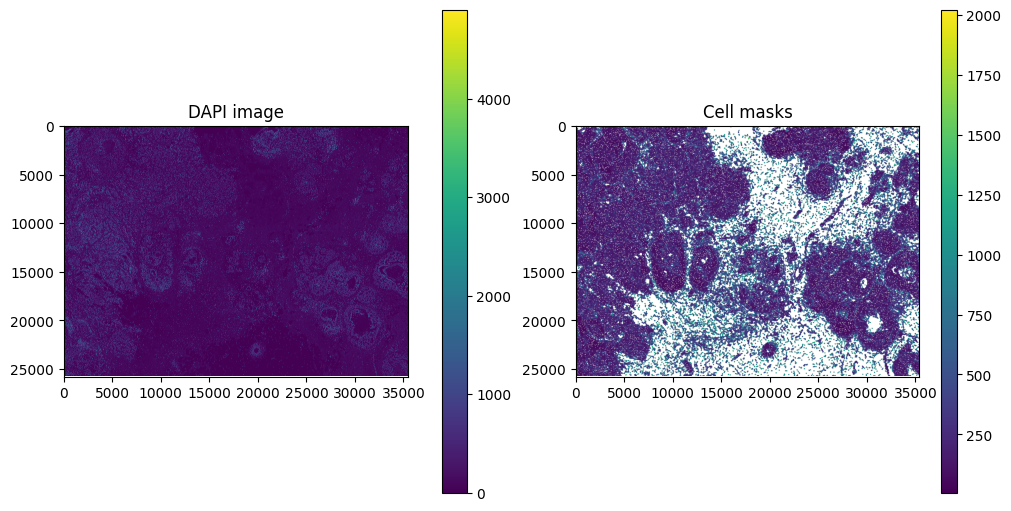

In [23]:
import matplotlib.pyplot as plt
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
sdata.pl.render_images("morphology_focus").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot - Cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata.pl.render_shapes("cell_boundaries", color="cell_area").pl.show(
    ax=axes[1], title="Cell masks", coordinate_systems="global"
)

In [24]:
bb_xmin = 10000
bb_ymin = 12500
bb_w = 2500
bb_h = 2500
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

In [25]:
def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )


sdata_xenium = crop(sdata)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


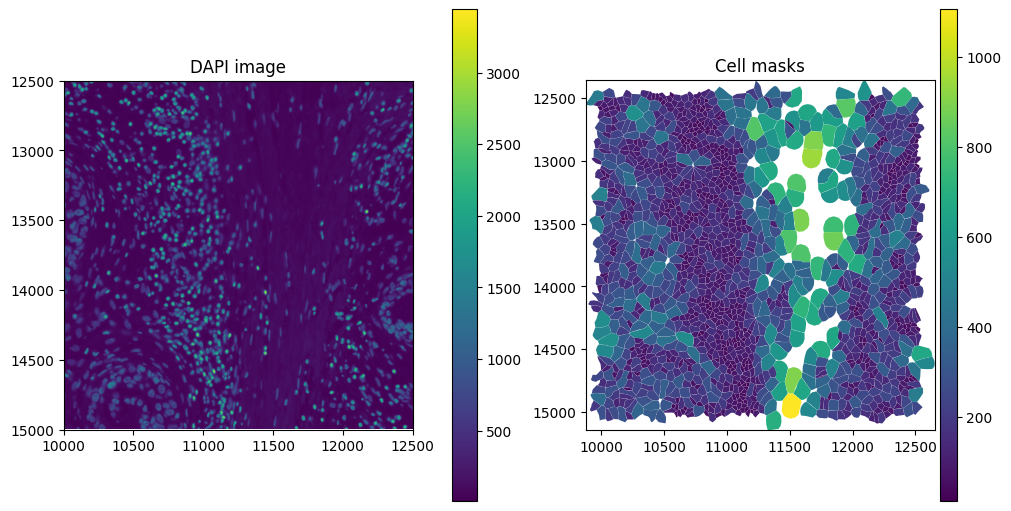

In [27]:
import matplotlib.pyplot as plt
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
sdata_xenium.pl.render_images("morphology_focus").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot - Cell boundaries
sdata_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata_xenium.pl.render_shapes("cell_boundaries", color="cell_area").pl.show(
    ax=axes[1], title="Cell masks", coordinate_systems="global"
)

## Proseg 3

Proseg 3 already provides a `SpatialData` object as output, which can be read in easily.

In [1]:
%load_ext autoreload
%autoreload 2

import spatialdata as sd

sdata = sd.read_zarr("../../data/proseg_output_v3/proseg-output.zarr/")
sdata

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: Fut

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/proseg_output_v3/proseg-output.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (17956, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (17956, 5095)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes)

Note that this object only contains one `cell_boundaries` layer in the shapes. To make full use of the 3D metrics of `SegTraQ`, we can also read in the segmentations at different z layers.

In [2]:
import gzip
import shutil
import warnings
from pathlib import Path

import geopandas as gpd

warnings.filterwarnings(
    "ignore",
    message="GeoSeries.notna.*previously returned False.*",
    category=UserWarning,
)


# adding the shapes for the different z layers
def decompress_geojson(gz_path: Path) -> Path:
    if gz_path.suffix == ".gz":
        json_path = gz_path.with_suffix("")  # strip .gz
        if not json_path.exists():
            with gzip.open(gz_path, "rt") as f_in, open(json_path, "w") as f_out:
                shutil.copyfileobj(f_in, f_out)
        return json_path
    return gz_path


path = Path("../../data/proseg_output_v3/")

# reading the polygons
polygons_gdf = gpd.read_file(decompress_geojson(path / "cell-polygons-layers.geojson.gz"))

# Polygon layers for multiple z stacks
for z in sorted(polygons_gdf["layer"].unique()):
    # select the current layer
    layer_gdf = polygons_gdf[polygons_gdf["layer"] == z]
    # filter out empty or missing geometries
    layer_gdf = layer_gdf[~layer_gdf.geometry.is_empty & layer_gdf.geometry.notna()]
    # putting everything into a spatialdata-compatible format
    layer_shapes = layer_gdf.set_index("cell")["geometry"].to_frame().copy()
    layer_shapes.index.name = "label_id"
    layer_shapes["cell_id"] = layer_shapes.index
    sdata.shapes[f"cell_boundaries_z{int(z)}"] = sd.models.ShapesModel.parse(layer_shapes)

sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/proseg_output_v3/proseg-output.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (17956, 2) (2D shapes)
│     ├── 'cell_boundaries_z0': GeoDataFrame shape: (17638, 2) (2D shapes)
│     ├── 'cell_boundaries_z1': GeoDataFrame shape: (17823, 2) (2D shapes)
│     ├── 'cell_boundaries_z2': GeoDataFrame shape: (17822, 2) (2D shapes)
│     └── 'cell_boundaries_z3': GeoDataFrame shape: (16450, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (17956, 5095)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_boundaries_z0 (Shapes), cell_boundaries_z1 (Shapes), cell_boundaries_z2 (Shapes), cell_boundaries_z3 (Shapes)
with the following elements not in the Zarr store:
    ▸ cell_boundaries_z2 (Shapes)
    ▸ cell_b

Some metrics in `SegTraQ` also depend on a nuclear segmentation mask. Here, we read in the nuclear segmentation provided by Xenium.

In [3]:
# adding nucleus boundaries from Xenium
import numpy as np
import pandas as pd
from shapely.geometry import MultiPolygon, Polygon
from shapely.validation import make_valid


# Convert a vertex table (one row per boundary vertex) into a GeoDataFrame of cell polygons.
def build_cell_polygons_from_vertices(
    df: pd.DataFrame,
    id_col: str = "label_id",
    x_col: str = "vertex_x",
    y_col: str = "vertex_y",
    keep_attrs=("cell_id",),
    drop_closed_duplicate: bool = True,
    fix_invalid: bool = True,
) -> gpd.GeoDataFrame:
    rows = []
    geometries = []

    for label_id, group in df.groupby(id_col, sort=False):
        xs = group[x_col].to_numpy()
        ys = group[y_col].to_numpy()

        # Drop last duplicate closing point if present
        if drop_closed_duplicate and len(xs) >= 2 and xs[0] == xs[-1] and ys[0] == ys[-1]:
            xs = xs[:-1]
            ys = ys[:-1]

        if len(xs) < 3:
            continue  # not enough points to form a polygon

        poly = Polygon(np.column_stack([xs, ys]))

        # Repair invalid polygons
        if fix_invalid and not poly.is_valid:
            poly = make_valid(poly)
            if poly.geom_type == "GeometryCollection":
                polys = [p for p in poly.geoms if p.geom_type in ("Polygon", "MultiPolygon")]
                if not polys:
                    continue
                poly = polys[0] if len(polys) == 1 else MultiPolygon(polys)

        if poly.is_empty:
            continue

        row = {id_col: int(label_id) if pd.notna(label_id) else None}
        for attr in keep_attrs:
            if attr in group.columns:
                row[attr] = group[attr].iloc[0]

        rows.append(row)
        geometries.append(poly)

    gdf = gpd.GeoDataFrame(rows, geometry=geometries)
    gdf.set_index(id_col, inplace=True)
    return gdf


nucleus_shapes = pd.read_parquet("../../data/nucleus_boundaries.parquet")
nucleus_shapes = build_cell_polygons_from_vertices(nucleus_shapes)
sdata.shapes["nucleus_boundaries"] = sd.models.ShapesModel.parse(nucleus_shapes)

# we also need to add the correct transformations to our new shapes
cell_shape_transformation = sd.transformations.get_transformation(sdata.shapes["cell_boundaries"])
sd.transformations.set_transformation(sdata.shapes["nucleus_boundaries"], cell_shape_transformation)

sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/proseg_output_v3/proseg-output.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (17956, 2) (2D shapes)
│     ├── 'cell_boundaries_z0': GeoDataFrame shape: (17638, 2) (2D shapes)
│     ├── 'cell_boundaries_z1': GeoDataFrame shape: (17823, 2) (2D shapes)
│     ├── 'cell_boundaries_z2': GeoDataFrame shape: (17822, 2) (2D shapes)
│     ├── 'cell_boundaries_z3': GeoDataFrame shape: (16450, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (18608, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (17956, 5095)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_boundaries_z0 (Shapes), cell_boundaries_z1 (Shapes), cell_boundaries_z2 (Shapes), cell_boundaries_z3 (Shapes), nucleus_boundaries (S

Finally, we can read these into SegTraQ. Don't worry if you do not know all of these parameters up front, you can start by simply passing an `sdata` object into the function and it will tell you exactly which parameters need to be set.

In [ ]:


segtraq.SegTraQ(
    sdata,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_volume_key="volume",
    shapes_cell_id_key="cell",
    tables_cell_id_key="cell",
    images_key=None,
    tables_x_key="centroid_x",
    tables_y_key="centroid_y",
)